# Snake and Ladder — Markov Chain Analysis

**Objective:** find how many turns Snake and Ladder actually takes to finish, how much each individual snake/ladder reshapes that, and how the number of dice used per turn changes the game.
**Method:** the board modeled as an absorbing Markov chain. The transition matrix is built directly in Python from the board layout and the dice-sum distribution -- not read from a fixed spreadsheet -- so the number of dice (`N_DICE`) is just a parameter, and the whole analysis can be re-run for any dice count.

Reference board layouts used while designing the board are in `../docs/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, ".")
import SnL_markov_chain as mc
import SnL_visualizations as viz
from SnL_report_builder import build_executive_report

RESULT_DIR = "../result"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
SLD_DIR = os.path.join(RESULT_DIR, "slides")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SLD_DIR, exist_ok=True)

## Parameters

Every input that shapes the analysis lives here, in one place, instead of buried as constants inside a module -- change the board layout or the dice count by editing this cell and re-running.

In [2]:
# Board size and layout -- classic Snake & Ladder, 9 ladders + 9 snakes.
BOARD_SIZE = 100
LADDERS = [(3, 24), (8, 14), (13, 31), (33, 54), (39, 58), (41, 85), (69, 95), (79, 98), (89, 91)]
SNAKES = [(25, 4), (30, 9), (45, 27), (51, 34), (61, 19), (74, 55), (93, 67), (97, 57), (99, 80)]

# Dice rolled per turn -- the main walkthrough (STEP 03-08) uses this value;
# STEP 09 re-runs the analysis across several dice counts to compare.
N_DICE = 1

## STEP 01 - Board Setup (Snakes & Ladders in Python)

The classic 100-square board layout -- 9 ladders, 9 snakes -- from the `LADDERS`/`SNAKES` lists set in Parameters above, turned into a DataFrame by `SnL_markov_chain.py` instead of an Excel sheet.

In [3]:
snake_ladder_df = mc.build_snake_ladder_df(LADDERS, SNAKES)
n_ladders = (snake_ladder_df["type"] == "Ladder").sum()
n_snakes = (snake_ladder_df["type"] == "Snake").sum()
print(f"Board: {BOARD_SIZE} squares | {n_ladders} ladders | {n_snakes} snakes")
snake_ladder_df

Board: 100 squares | 9 ladders | 9 snakes


,start,finish,type,distance
0,3,24,Ladder,21
1,8,14,Ladder,6
2,13,31,Ladder,18
3,25,4,Snake,-21
4,30,9,Snake,-21
5,33,54,Ladder,21
6,39,58,Ladder,19
7,41,85,Ladder,44
8,45,27,Snake,-18
9,51,34,Snake,-17


## STEP 02 - Build the Transition Matrix Dynamically

`build_transition_matrix(n_dice)` computes the dice-sum distribution for `n_dice` standard 6-sided dice (e.g. 2 dice: sums 2-12, triangular around 7), applies the "bounce back on overshoot" rule, and redirects any square that is a snake/ladder start straight to its finish -- all from the board layout above, no lookup table. The main walkthrough below uses the `N_DICE` set in Parameters; STEP 09 re-runs this for several dice counts to compare.

In [4]:
transition_matrix = mc.build_transition_matrix(n_dice=N_DICE, board_size=BOARD_SIZE, snake_ladder_df=snake_ladder_df)
print(f"Transition matrix: {transition_matrix.shape}, built for {N_DICE} dice")
print(f"Dice-sum distribution: {mc.dice_sum_distribution(N_DICE)}")
pd.DataFrame(transition_matrix).iloc[:5, :5]

Transition matrix: (100, 100), built for 1 dice
Dice-sum distribution: {1: 0.16666666666666666, 2: 0.16666666666666666, 3: 0.16666666666666666, 4: 0.16666666666666666, 5: 0.16666666666666666, 6: 0.16666666666666666}


,0,1,2,3,4
0,0.0,0.166667,0.166667,0.166667,0.166667
1,0.0,0.000000,0.166667,0.166667,0.166667
2,0.0,0.000000,0.000000,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.166667
4,0.0,0.000000,0.000000,0.000000,0.000000


## STEP 03 - Expected Steps to Finish

The fundamental matrix N = (I - Q)^-1, where Q excludes the absorbing (finish) state, gives the expected number of turns from every position.

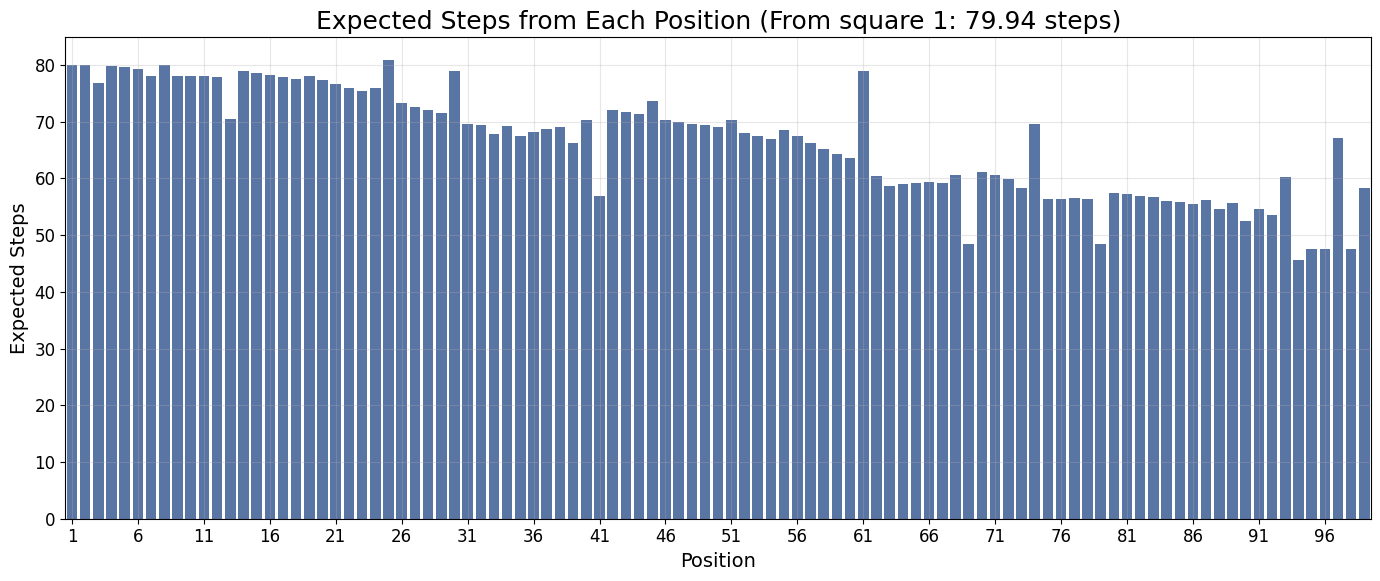

From the starting position (square 1), the game takes 79.94 turns on average to finish
Best position: Square 94 (averages 45.65 steps)
Worst position: Square 25 (averages 80.83 steps)


In [5]:
expected_steps = mc.analyze_expected_steps(transition_matrix)
viz.plot_expected_steps(expected_steps, os.path.join(FIG_DIR, "expected_steps.png"))
plt.show()

print(f"From the starting position (square 1), the game takes {expected_steps[0]:.2f} turns on average to finish")
best_pos = np.argmin(expected_steps) + 1
worst_pos = np.argmax(expected_steps) + 1
print(f"Best position: Square {best_pos} (averages {expected_steps[best_pos-1]:.2f} steps)")
print(f"Worst position: Square {worst_pos} (averages {expected_steps[worst_pos-1]:.2f} steps)")

## STEP 04 - Fastest Probabilistic Route

Starting from square 1, always advance to whichever reachable square has the lowest expected remaining steps.

In [6]:
fastest_route = mc.find_fastest_route(transition_matrix, expected_steps)
print(f"Route: {fastest_route}")
print(f"Number of steps: {len(fastest_route)-1}")

for i in range(len(fastest_route)-1):
    current, next_pos = fastest_route[i], fastest_route[i+1]
    sl_info = snake_ladder_df[snake_ladder_df["start"] == current]
    if not sl_info.empty:
        print(f"Step {i+1}: From square {current} -> {next_pos} ({sl_info['type'].values[0]})")
    else:
        print(f"Step {i+1}: From square {current} -> {next_pos} (Forward {next_pos - current} steps)")

Route: [1, 3, 24, 29, 35, 41, 85, 90, 94, 100]
Number of steps: 9
Step 1: From square 1 -> 3 (Forward 2 steps)
Step 2: From square 3 -> 24 (Ladder)
Step 3: From square 24 -> 29 (Forward 5 steps)
Step 4: From square 29 -> 35 (Forward 6 steps)
Step 5: From square 35 -> 41 (Forward 6 steps)
Step 6: From square 41 -> 85 (Ladder)
Step 7: From square 85 -> 90 (Forward 5 steps)
Step 8: From square 90 -> 94 (Forward 4 steps)
Step 9: From square 94 -> 100 (Forward 6 steps)


## STEP 05 - Board Heatmap Dashboard

The board laid out as a real 10x10 grid, colored by expected steps to finish from each square.

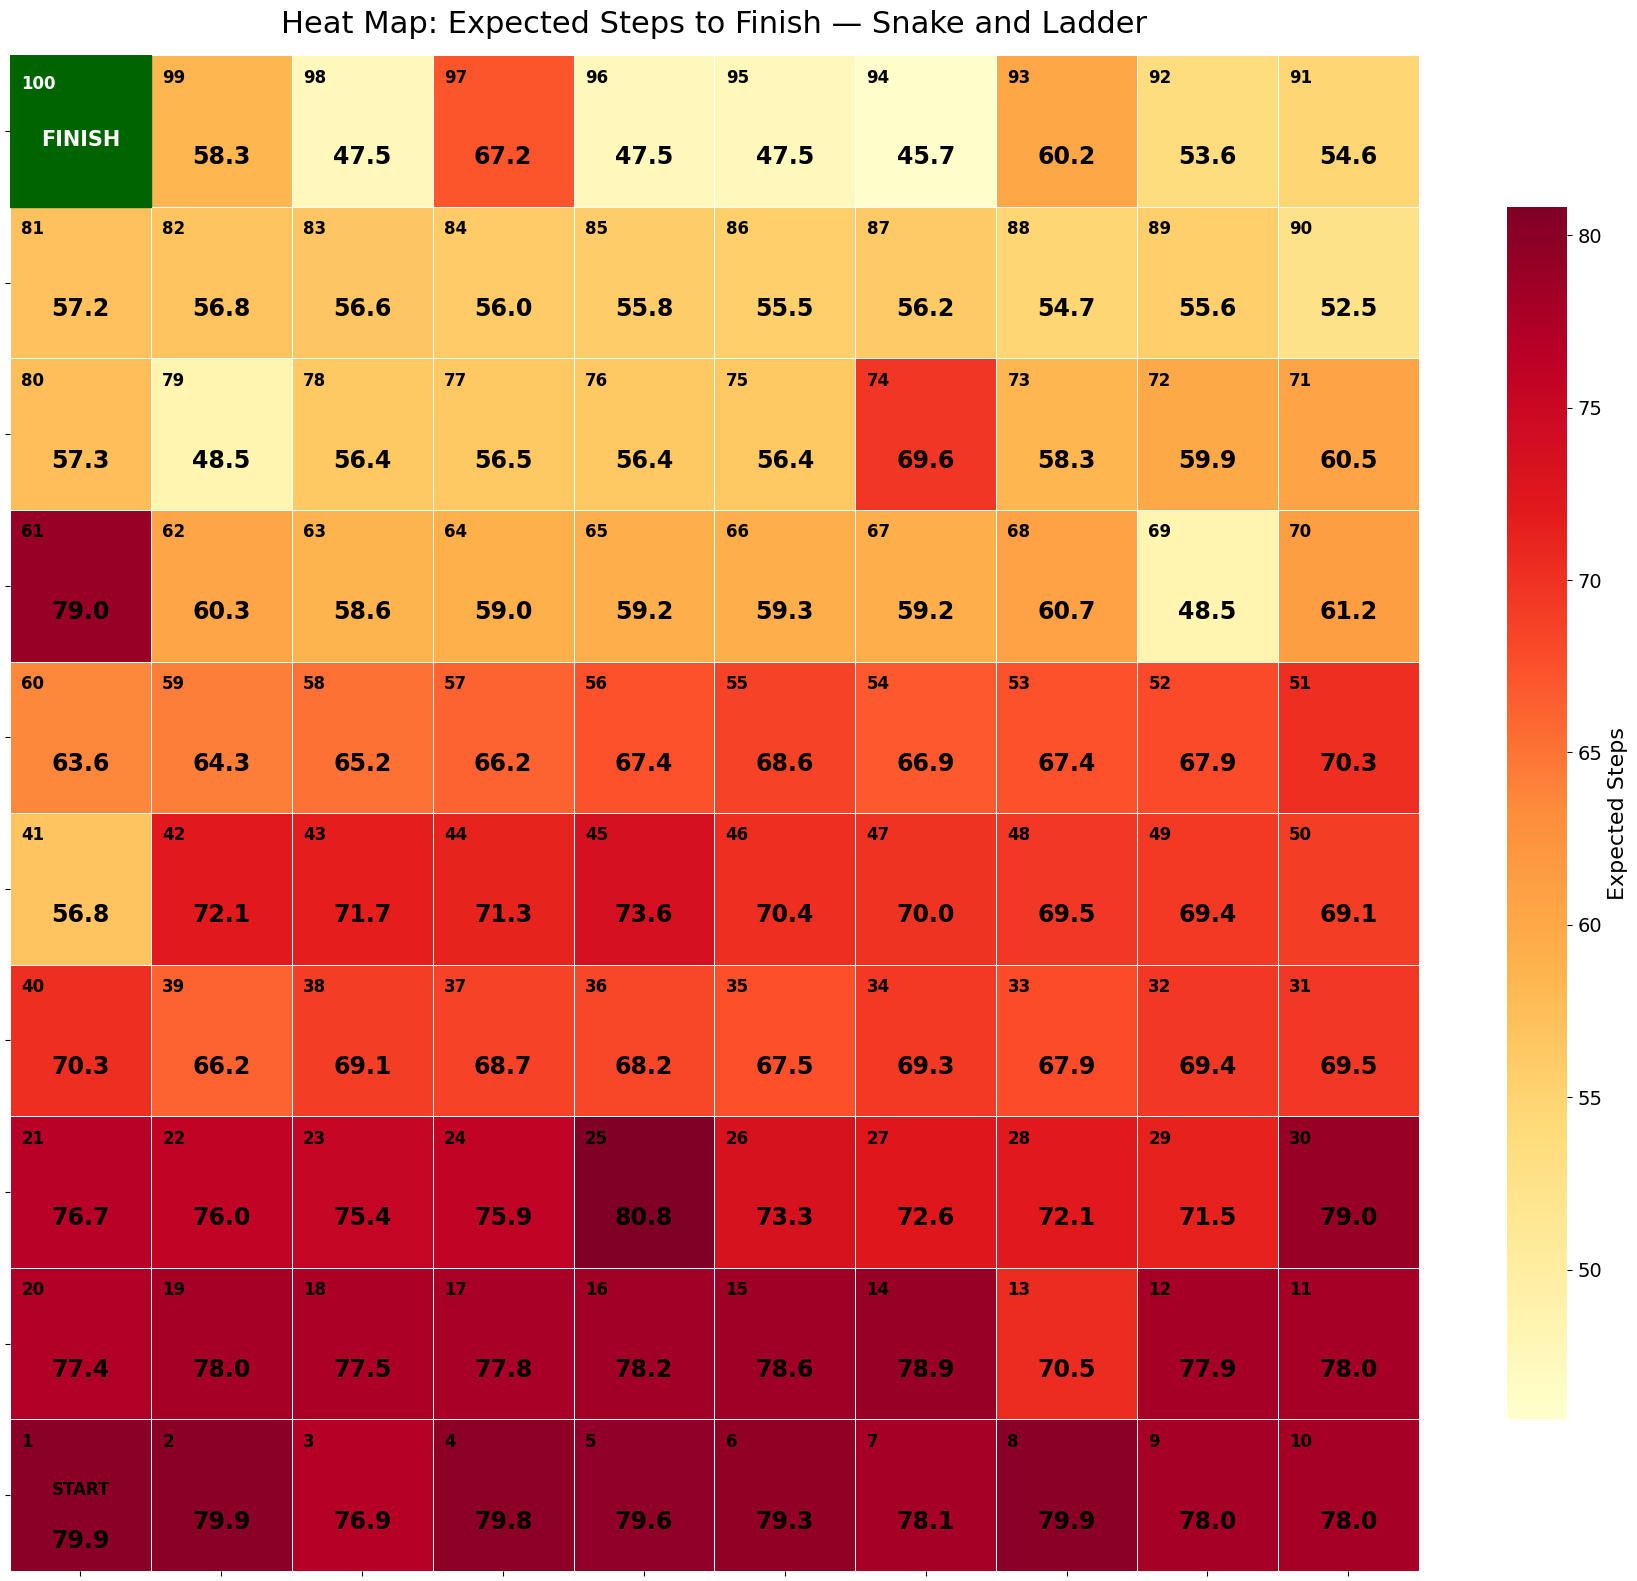

In [7]:
heatmap_img = viz.plot_board_heatmap(expected_steps, os.path.join(FIG_DIR, "board_heatmap.png"))
plt.show()

## STEP 06 - Snake and Ladder Impact

For each snake/ladder, compare expected turns from square 1 with vs. without that element (its start square instead behaves like a normal square).

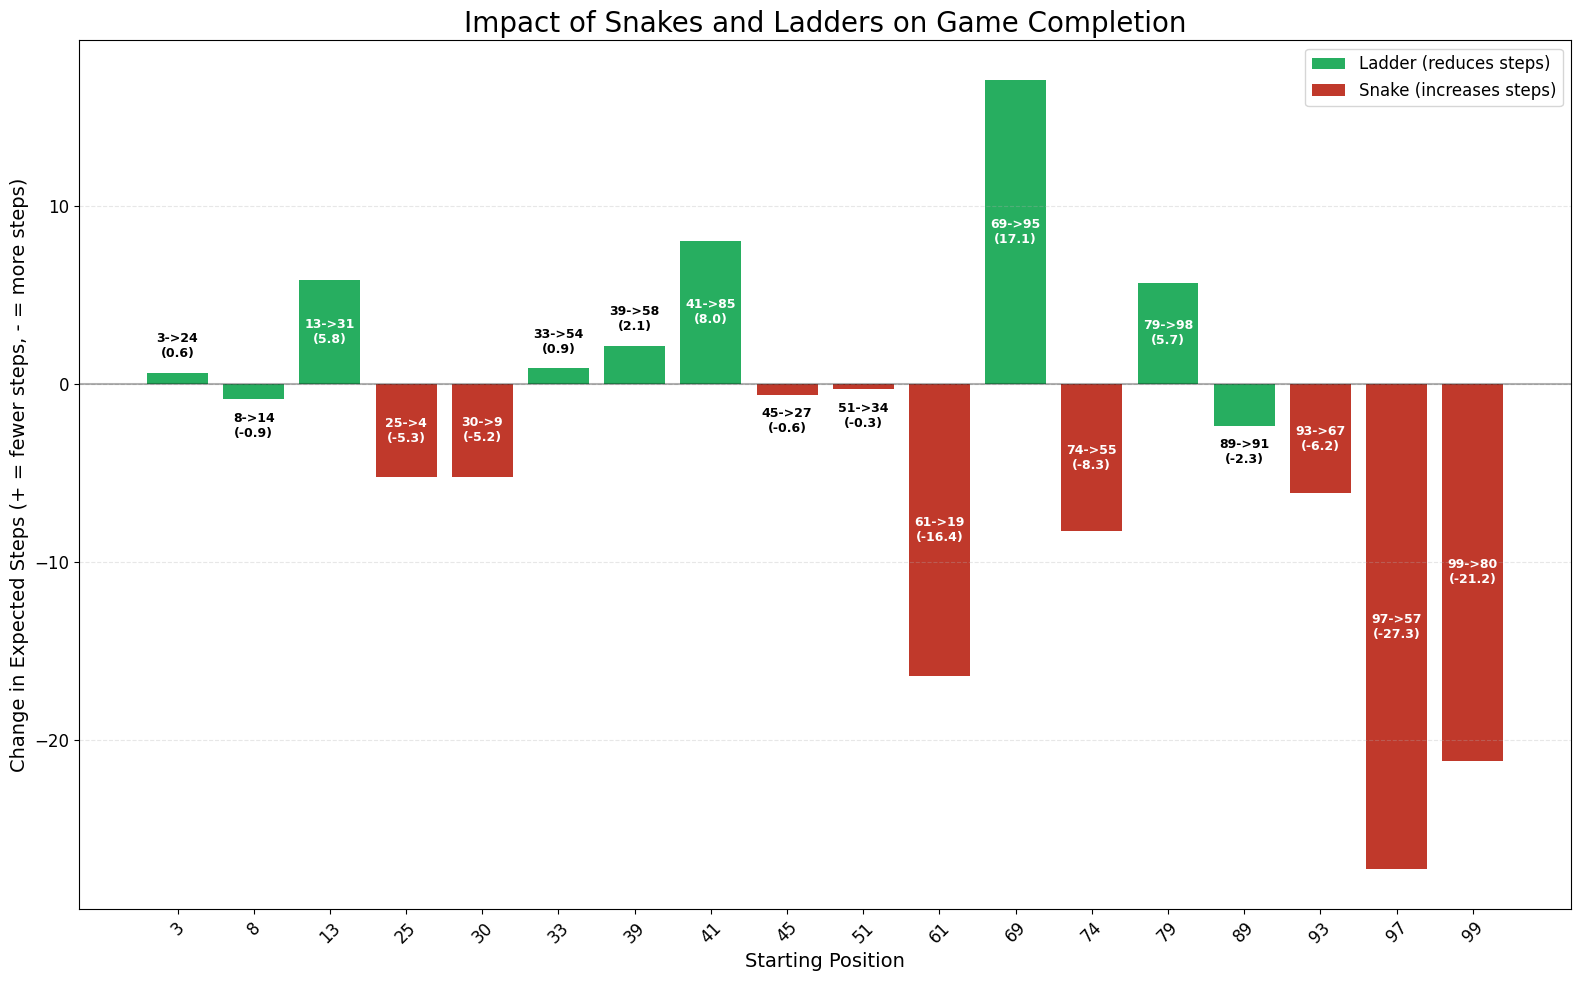

Total steps saved by ladders: 37.04
Total steps added by snakes: -90.78
Net impact: -53.74 steps

Elements with the largest impact:
Snake 97->57: adds 27.30 steps
Snake 99->80: adds 21.19 steps
Ladder 69->95: reduces 17.09 steps


In [8]:
impact_df = mc.snake_ladder_impact(transition_matrix, snake_ladder_df, n_dice=N_DICE, board_size=BOARD_SIZE)
impact_img = viz.plot_snl_impact(impact_df, os.path.join(FIG_DIR, "snl_impact.png"))
plt.show()

ladder_impact = impact_df.loc[impact_df["Type"] == "Ladder", "Impact"].sum()
snake_impact = impact_df.loc[impact_df["Type"] == "Snake", "Impact"].sum()
print(f"Total steps saved by ladders: {ladder_impact:.2f}")
print(f"Total steps added by snakes: {snake_impact:.2f}")
print(f"Net impact: {ladder_impact + snake_impact:.2f} steps")

impact_df["AbsImpact"] = impact_df["Impact"].abs()
top_impacts = impact_df.sort_values("AbsImpact", ascending=False).head(3)
impact_findings = []
print("\nElements with the largest impact:")
for _, row in top_impacts.iterrows():
    effect = "reduces" if row["Impact"] > 0 else "adds"
    line = f"{row['Type']} {int(row['Start'])}->{int(row['End'])}: {effect} {abs(row['Impact']):.2f} steps"
    print(line)
    impact_findings.append(f"Biggest impact: {line}" if len(impact_findings) == 0 else line)

## STEP 07 - Position Distribution Over Time

Where is a player likely to be after N turns, and how much probability mass has reached the finish square by then?

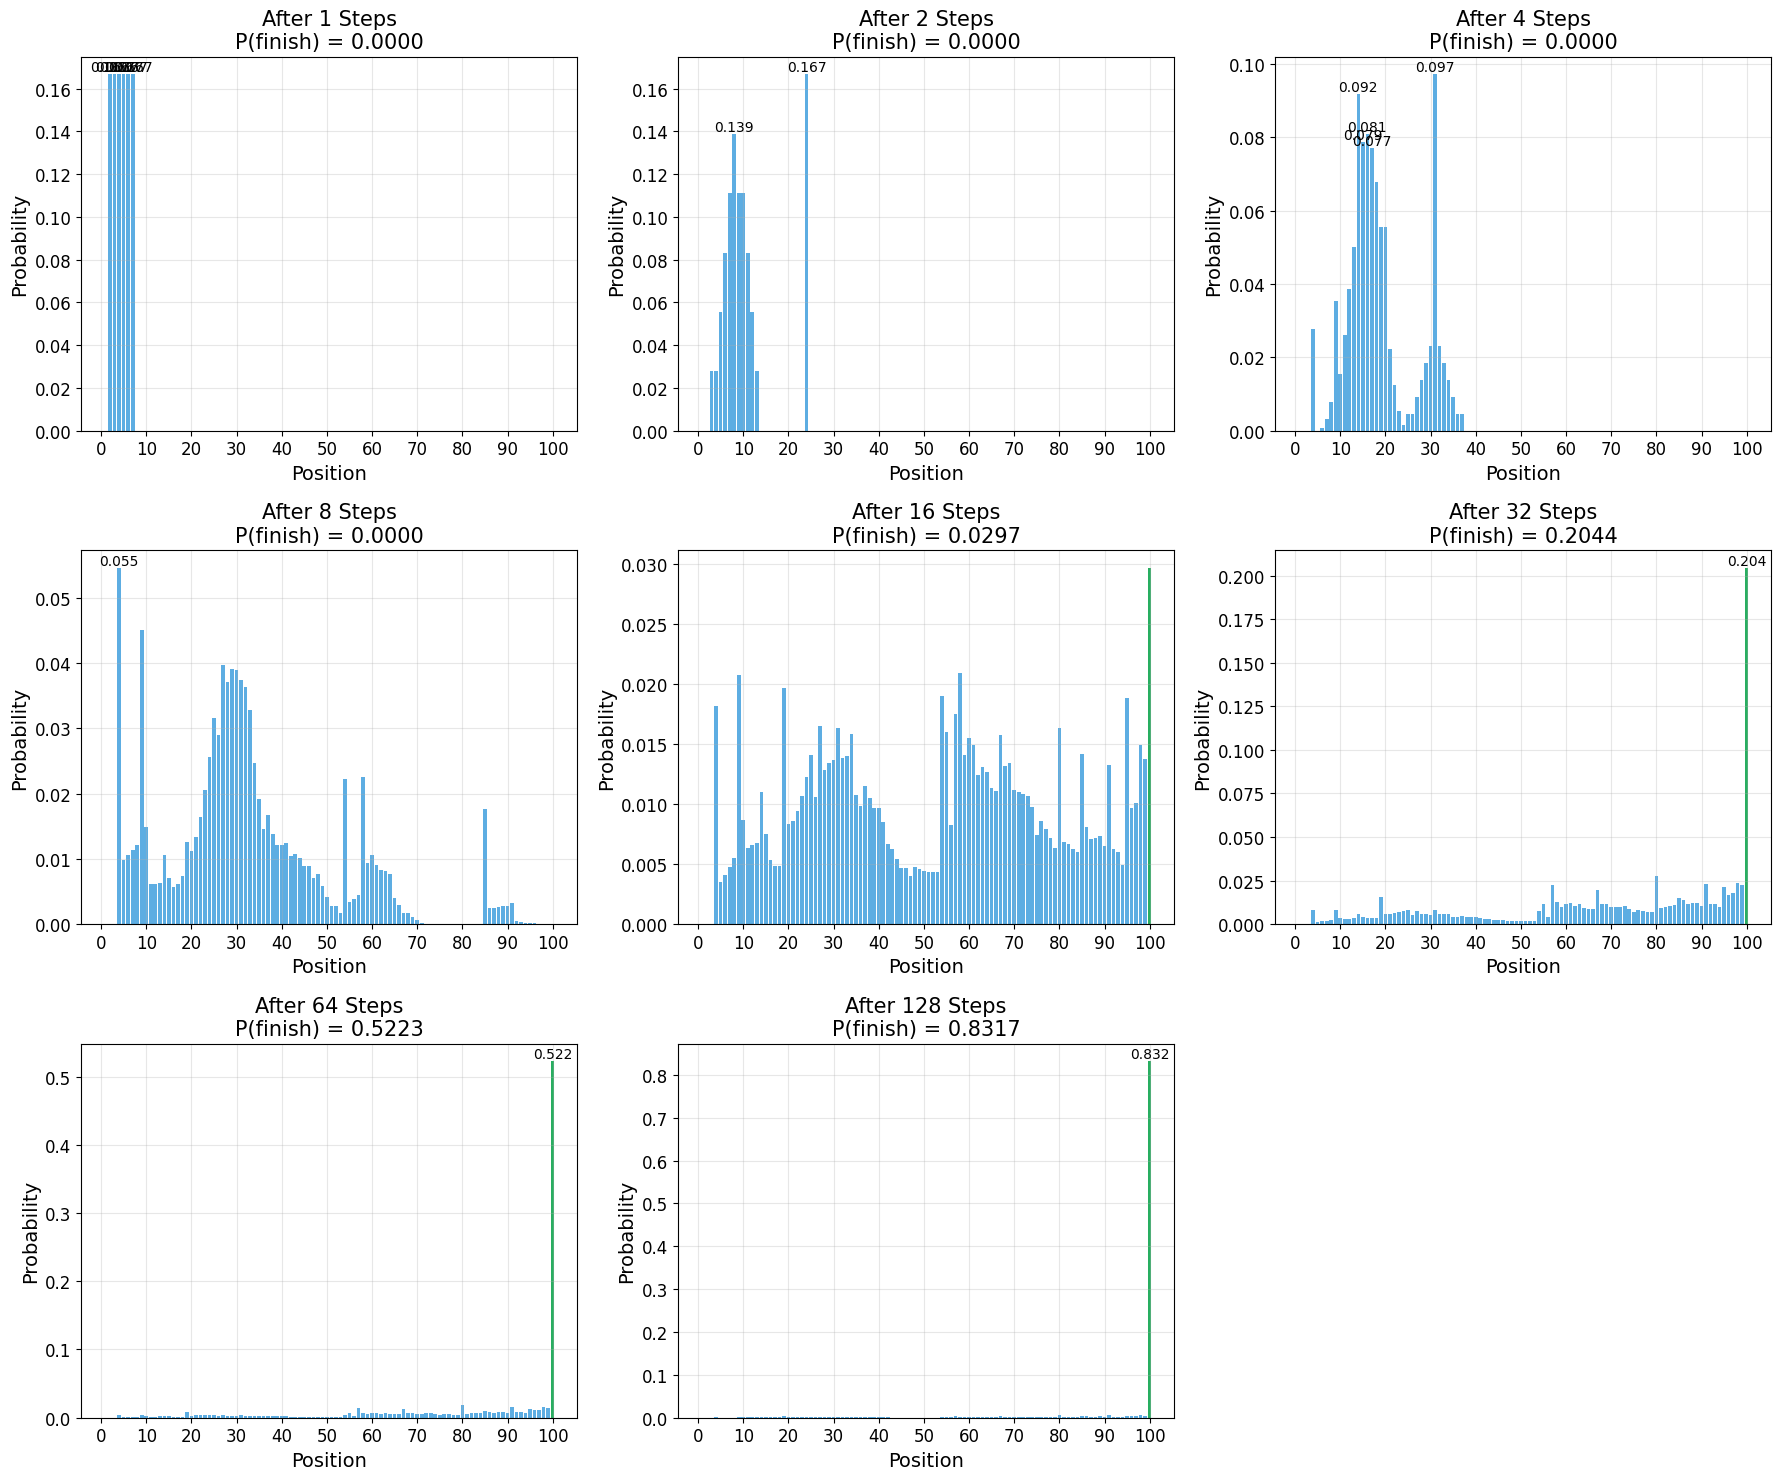

In [9]:
distributions = mc.position_distribution_over_steps(transition_matrix, steps=[1, 2, 4, 8, 16, 32, 64, 128])
viz.plot_position_distribution(distributions, os.path.join(FIG_DIR, "position_distribution.png"))
plt.show()

## STEP 08 - Finish-Time Distribution

Distribution and cumulative probability of finishing the game at/within a given number of steps.

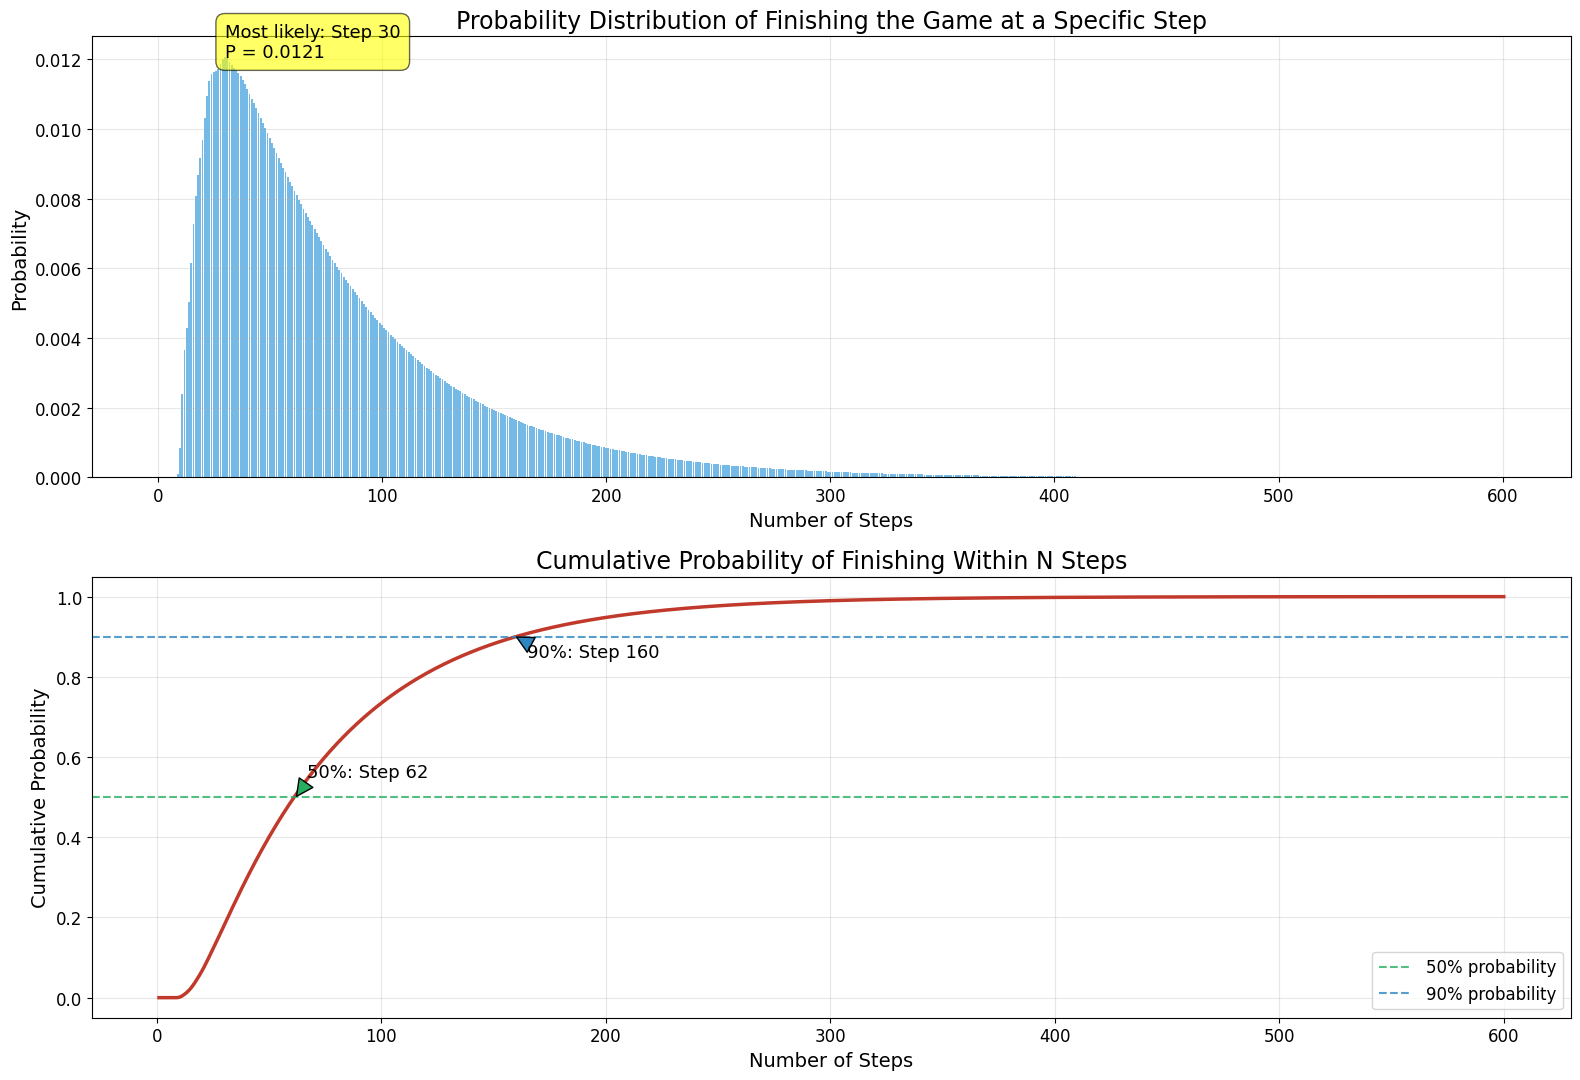

Game Completion Statistics:
----------------------------------------
Step with highest probability: 30 (P = 0.0121)
Mean (expected steps, exact): 79.94 steps
Standard deviation (exact): 61.86 steps

Completion percentiles:
10%: 24 steps
25%: 36 steps
50%: 62 steps
75%: 104 steps
90%: 160 steps
95%: 203 steps
99%: 302 steps


In [10]:
finish_df = mc.finish_time_distribution(transition_matrix, max_steps=600)
finish_img = viz.plot_finish_distribution(finish_df, os.path.join(FIG_DIR, "finish_probability_density.png"))
plt.show()

# Mean/std come from the exact fundamental-matrix formulas (analyze_expected_steps,
# variance_of_steps), not by averaging the finish_df density -- that distribution
# has a long right tail, so any step cap understates both if used directly.
mean_steps = expected_steps[0]
std_steps = np.sqrt(mc.variance_of_steps(transition_matrix)[0])
max_row = finish_df.loc[finish_df["density"].idxmax()]

percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_steps = {}
print("Game Completion Statistics:")
print("-" * 40)
print(f"Step with highest probability: {int(max_row['step'])} (P = {max_row['density']:.4f})")
print(f"Mean (expected steps, exact): {mean_steps:.2f} steps")
print(f"Standard deviation (exact): {std_steps:.2f} steps")
print("\nCompletion percentiles:")
for p in percentiles:
    step = finish_df.loc[finish_df["cumulative"] >= p/100, "step"].min()
    percentile_steps[p] = step
    print(f"{p}%: {int(step) if pd.notna(step) else f'>{len(finish_df)}'} steps")

finish_stats = {
    "median": percentile_steps[50],
    "p90": percentile_steps[90],
    "mean": mean_steps,
    "std": std_steps,
}

## STEP 09 - Dice Count Comparison

Because the transition matrix is built in code, not read from a spreadsheet, the same analysis re-runs for any number of dice -- this is the direct payoff of the dynamic matrix builder from STEP 02.

1 dice/turn -> 79.94 expected turns to finish
2 dice/turn -> 50.80 expected turns to finish
3 dice/turn -> 45.49 expected turns to finish
4 dice/turn -> 47.75 expected turns to finish
5 dice/turn -> 46.99 expected turns to finish
6 dice/turn -> 53.26 expected turns to finish
7 dice/turn -> 68.89 expected turns to finish


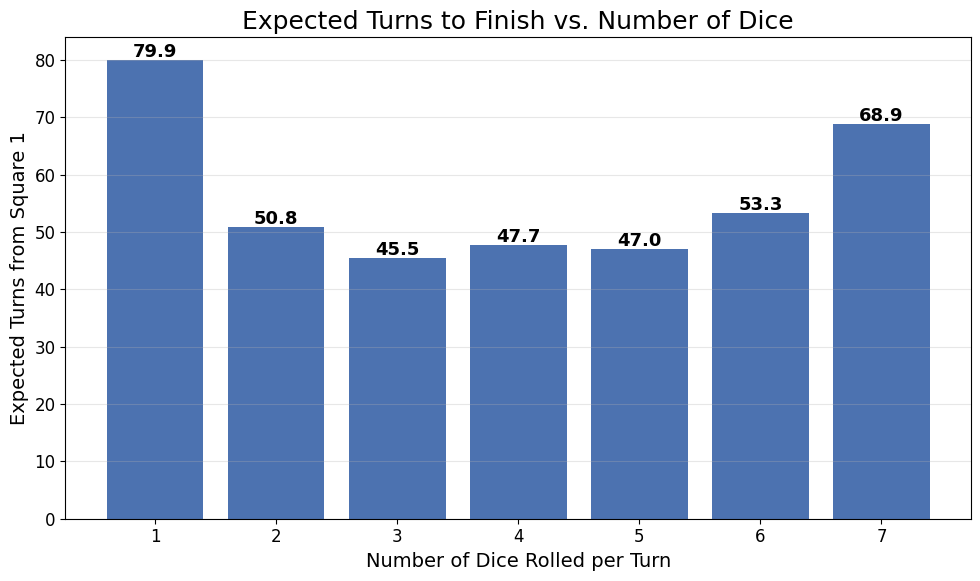

In [11]:
dice_options = range(1, 8)
comparison_rows = []
for n_dice in dice_options:
    m = mc.build_transition_matrix(n_dice=n_dice, board_size=BOARD_SIZE, snake_ladder_df=snake_ladder_df)
    steps_from_start = mc.analyze_expected_steps(m)[0]
    comparison_rows.append({"n_dice": n_dice, "expected_steps": steps_from_start})
    print(f"{n_dice} dice/turn -> {steps_from_start:.2f} expected turns to finish")

comparison_df = pd.DataFrame(comparison_rows)
dice_comparison_img = viz.plot_dice_comparison(comparison_df, os.path.join(FIG_DIR, "dice_comparison.png"))
plt.show()

## STEP 10 - Build the Executive Report

Summary, board heatmap, snake/ladder impact, finish-time distribution, and the dice-count comparison. Design lives in `SnL_report_builder.py`, same pattern as this portfolio's other executive reports, including the `result/figures/` + `result/slides/` output layout.

In [12]:
report_path = build_executive_report(
    n_dice=N_DICE, board_size=BOARD_SIZE, expected_steps_from_start=expected_steps[0],
    n_ladders=int(n_ladders), n_snakes=int(n_snakes),
    heatmap_img=heatmap_img, impact_img=impact_img, impact_findings=impact_findings,
    finish_img=finish_img, finish_stats=finish_stats,
    dice_comparison_img=dice_comparison_img,
    output_dir=RESULT_DIR,
)
print(f"Report saved to {report_path}")

Report saved to ../result\slides\Executive_SnakeLadder_Report_20260830.pptx


## Conclusion

With 1 die per turn, the game takes **79.94 turns on average** from square 1 -- but with a standard deviation of **61.86 turns**, this is a genuinely high-variance game: the median is only 62 turns, the most likely single outcome is 30, and the 90th percentile is 160 turns. Mean and median disagree by that much because the finish-time distribution has a long right tail (visible in the density chart) -- most games finish reasonably fast, but a meaningful minority drag on far past the average. Square 94 is the luckiest square to be on (45.65 expected turns to finish) and square 25 the unluckiest (80.83), which the board heatmap shows directly.

The 9 ladders save a combined 37.0 turns; the 9 snakes add a combined 90.8 -- the board is net unfavorable by design (-53.7 turns), and the single biggest swing is the snake at 97 (adds 27.3 turns on its own, since it strikes right before the finish). Two short ladders (8→14 and 89→91) show a small *negative* net impact once interactions with the rest of the board are accounted for -- a reminder that in a system this interconnected, "shorter path" doesn't always mean "faster game" once every other element is still in play.

Because the transition matrix is now built in code instead of read from a spreadsheet, the dice-count comparison in STEP 09 is a direct, free extension: 2 dice cuts the average game to 50.8 turns and 3 dice to 45.5, but 4 dice is *slightly worse* than 3 (47.8) -- bigger rolls overshoot the board more often near the end, and the bounce-back penalty starts to offset the raw speed gain. There's a real optimum, not a monotonic "more dice is always faster."

Rebuilding the matrix in Python also surfaced and fixed a real bug in the old hand-built Excel data: the 2-dice sheet's finish square wasn't actually self-absorbing (it had outgoing "bounce-back" transitions as if still in play), which would have silently corrupted any multi-step probability analysis run on it.

**Bottom line:** expect roughly 60-90 turns to finish depending on luck, plan for high variance rather than a single number, and if you get to design the dice count, 3 beats both 2 and 4.